<center>
    <img src="https://avatars.githubusercontent.com/u/192127829?s=100" alt="Logo Pyvoa" /> 
</center>

# pyvoa — illustrative examples of the software paper

**pyvoa: a Python framework for unified access, standardisation and visualisation
of open epidemiological data**
T. Beau, J. Browaeys, O. Dadoun — submitted to *SoftwareX*

This notebook runs every code listing of the manuscript, in the order in which
they appear, and produces the manuscript figures. Each code cell below is
**identical to the listing printed in the paper**, so that what is published and
what is executed can be compared line by line rather than trusted.

Two cells are not manuscript listings and are labelled as such: the standalone
use of the geolocation layer (§2.1 and §4), and the wastewater / reported
incidence comparison that illustrates §4, point 1.

Run order matters only in that `setwhom()` selects the active database; each
example sets its own, so cells can also be run individually.

| | |
|---|---|
| repository | <https://github.com/pyvoa/pyvoa> |
| documentation | <https://pyvoa.github.io/pyvoa> |
| archived release | <https://doi.org/10.5281/zenodo.21829901> |
| licence | MIT |

## 0. Setup

`pyvoa` alone returns data; `pyvoa-full` adds the plotting backends, which the
figures below need. On Google Colab or Binder, run the install cell once; on a
local machine where the package is already installed, skip it.

The first `setwhom()` of a session downloads the dataset into
`~/.cache/pyvoa.data_<user>/` and takes a few minutes. Later runs read the cache,
and `setwhom(db, reload=False)` reuses it without checking upstream at all.

In [3]:
# Run once on Colab / Binder, or on a fresh environment.
# %pip install pyvoa-full

In [1]:
cd ../..

/home/beau/cernbox/Git/pyvoa


In [2]:
import pyvoa.front as pf

pf.set_verbose_mode(1)          # 0 silent, 1 info, 2 debug
print('pyvoa', pf.getversion())

Loading BokehJS ...

 ✨ Welcome to PyVOA (version 0.5.0) ✨
See https://pyvoa.org
pyvoa 0.5.0


### Figure directory

The listing cells below spell out their arguments literally, so that each is
character-for-character the listing printed in the paper. Nothing is factored
out into a variable: a listing that reads `when=JHU_DATE` in the notebook and
`when='31/12/2021'` in the paper cannot be compared line by line, which is the
whole point of this file.

In [3]:
from pathlib import Path

# The figures belong next to the manuscript that includes them, which is where
# paper_examples.py writes them too. Falls back to ./figures when this notebook
# is run outside a checkout (Colab, a downloaded copy).
FIGDIR = Path('../../paper/figures')
if not FIGDIR.parent.exists():
    FIGDIR = Path('./figures')
FIGDIR.mkdir(parents=True, exist_ok=True)

def save(name):
    '''Write the current figure into FIGDIR. Never abort a run on failure:
    savefig support differs between backends.'''
    try:
        pf.savefig(str(FIGDIR / name))
        print('->', FIGDIR / name)
    except Exception as exc:
        print('!! savefig failed for', name, ':', exc)

## 1. Vocabulary check *(recommended before submission)*

This cell asserts that every database, indicator, option and grouping cited in
the manuscript exists in the installed version. It guards against the class of
error that made the first draft's listings unrunnable: a database that was never
in the catalogue, an option renamed in 0.4.0, an indicator absent from the
source's JSON descriptor.

Run it again after every version bump.

In [ ]:
failures = []

def want(label, value, allowed):
    if value in allowed:
        print(f'  ok   {label}: {value!r}')
    else:
        failures.append(f'{label}: {value!r} not in {sorted(allowed)}')
        print(f'  FAIL {label}: {value!r}')

def want_ci(label, value, allowed):
    '''As want(), but case-insensitively: listwhere() answers in the source's
    own casing, which is not the casing a listing is written in.'''
    want(label, value.upper(), {str(a).upper() for a in allowed})

whom = set(pf.listwhom())
for db in ('owid', 'jhu', 'spf', 'ebolardc', 'spfnational', 'sumeau'):
    want('database', db, whom)

want('what',   'daily',           set(pf.listwhat()))
want('what',   'current',         set(pf.listwhat()))
want('option', 'smooth7',         set(pf.listoption()))
want('option', 'normalize:pop1M', set(pf.listoption()))
want('output', 'pandas',          set(pf.listoutput()))

# listhist() reads the chart vocabulary of the selected backend, so it raises
# until setvis() has been called. Only 'pie' is asked for by name below; the
# other three listings take the default chart of their method.
want('vis', 'matplotlib', set(pf.listvis()))
pf.setvis('matplotlib')
want('typeofhist', 'pie', set(pf.listhist()))

print('\nindicators and groupings (needs setwhom, hence a download):')
for db, indicators, groupings in (('owid',        ('total_deaths',),  ('Western Europe',)),
                                  ('jhu',         ('tot_confirmed',), ('G20',)),
                                  ('spf',         ('cur_hosp',),      ()),
                                  ('ebolardc',    ('tot_confirmed',), ()),
                                  ('spfnational', ('cur_cas',),       ()),
                                  ('sumeau',      ('ratio',),         ())):
    try:
        pf.setwhom(db, reload=False)
        available = set(pf.listwhich())
        for ind in indicators:
            want(f'{db}.which', ind, available)
        for g in groupings:
            want_ci(f'{db}.where', g, pf.listwhere())
    except Exception as exc:
        failures.append(f'setwhom({db!r}) raised {exc}')
        print(f'  FAIL setwhom({db!r}): {exc}')

print()
if failures:
    print(f'{len(failures)} problem(s):')
    for f in failures:
        print(' -', f)
else:
    print('all listings use a vocabulary the installed pyvoa recognises.')

## 2. Example 1 — comparing countries *(manuscript listing, Fig. 2)*

`where='Western Europe'` expands to the nine member states of the UN geoscheme
subregion through `GeoRegion` — Switzerland, Liechtenstein and Monaco among
them, so the grouping is not the European Union and does not have to be.
`what='daily'` differentiates the cumulative series the source publishes, and
`option='smooth7'` applies a weekly rolling mean, removing the reporting-day
artefact visible in every national series.

Few information concernant the selected database :  owid
Available key-words, which ∈ ['cur_excess_mortality', 'cur_excess_mortality_cumulative_per_million', 'cur_hosp_patients', 'cur_icu_patients', 'cur_idx_positive_rate', 'cur_reproduction_rate', 'cur_weekly_hosp_admissions', 'total_boosters', 'total_cases', 'total_cases_per_million', 'total_deaths', 'total_deaths_per_million', 'total_gdp_per_capita', 'total_people_fully_vaccinated', 'total_people_vaccinated', 'total_people_vaccinated_per_hundred', 'total_tests', 'total_tests_per_thousand', 'total_vaccinations', 'total_vaccinations_per_hundred']
Example of where :  ['Commonwealth', 'FSM', 'PER', 'Guadeloupe', 'Melanesia']  ...
Last date data  2024-08-14
First date data  2020-01-01


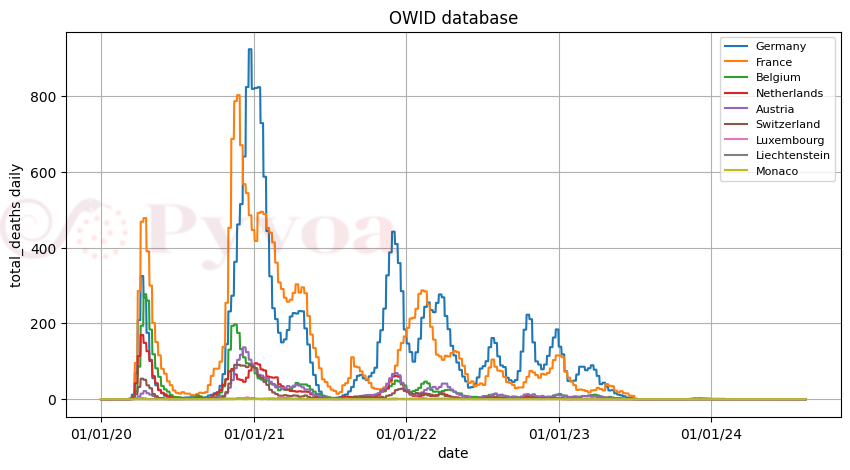

<Axes: title={'center': 'OWID database'}, xlabel='date', ylabel='total_deaths daily'>

In [4]:
import pyvoa.front as pf
pf.setwhom('owid')            # Our World in Data, worldwide, by country
pf.setvis('matplotlib')
pf.plot(which='total_deaths', where='Western Europe',
        what='daily', option='smooth7')

In [5]:
save('fig2_timeseries_weu.pdf')

Figure : figures/fig2_timeseries_weu.pdf  has been saved 
-> figures/fig2_timeseries_weu.pdf


## 3. Example 2 — mapping a grouping *(manuscript listing, Fig. 3)*

One keyword selects the G20 member states and the geolocation layer supplies
their geometries; the countries outside the grouping stay unpainted. The JHU
series is read from its Zenodo mirror, upstream collection having ended in
March 2023, so `when='31/12/2021'` picks a date the source actually covers.

Few information concernant the selected database :  jhu
Available key-words, which ∈ ['tot_confirmed', 'tot_deaths', 'tot_recovered']
Example of where :  ['ETH', 'WSM', 'OMN', 'Greece', 'Honduras']  ...
Last date data  2023-03-09
First date data  2020-01-22


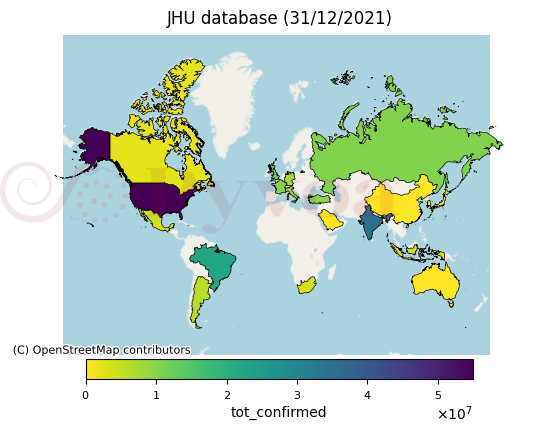

<Axes: title={'center': 'JHU database (31/12/2021)'}>

In [6]:
pf.setwhom('jhu')             # Johns Hopkins CSSE, worldwide
pf.map(which='tot_confirmed', where='G20', when='31/12/2021')

In [7]:
save('fig3_map_g20.pdf')

Figure : figures/fig3_map_g20.pdf  has been saved 
-> figures/fig3_map_g20.pdf


## 4. Example 3 — sub-national data, ranked and normalised *(manuscript listing, Fig. 4)*

The same four keywords address a French source at *département* granularity.
`option='normalize:pop1M'` divides by the population the geolocation layer
carries, turning a count into a rate per million inhabitants — which is what
makes départements of very different sizes comparable at all. The bars are
ranked by value rather than by name, and only the largest are drawn.

Few information concernant the selected database :  spf
Available key-words, which ∈ ['cur_hosp', 'cur_idx_R', 'cur_idx_tx_incid', 'cur_idx_tx_occupation_sae', 'cur_nb_A0', 'cur_nb_A1', 'cur_nb_C0', 'cur_nb_C1', 'cur_rea', 'cur_tx_A1', 'cur_tx_C1', 'cur_tx_pos', 'incid_dchosp', 'incid_hosp', 'incid_rad', 'incid_rea', 'tot_P', 'tot_T', 'tot_dchosp', 'tot_rad', 'tot_vacc1', 'tot_vacc2_rappel', 'tot_vacc_complet', 'tot_vacc_rappel']
Example of where :  ['Oise', 'Sarthe', 'Gironde', 'Haute-Savoie', 'Vaucluse']  ...
Last date data  2023-07-10
First date data  2020-03-18


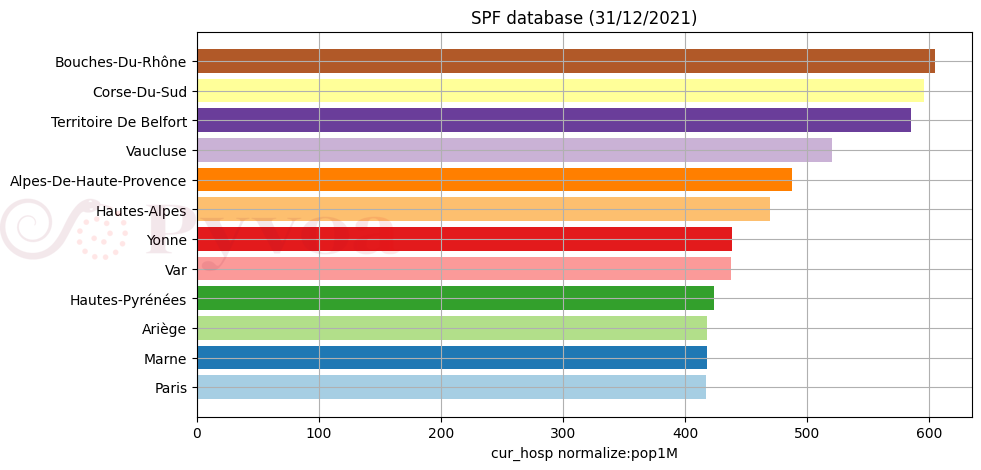

In [8]:
pf.setwhom('spf')    # Sante Publique France db
pf.hist(which='cur_hosp',when='31/12/2021',option='normalize:pop1M')

In [9]:
save('fig4_hist_spf.pdf')

Figure : figures/fig4_hist_spf.pdf  has been saved 
-> figures/fig4_hist_spf.pdf


In [15]:
pf.setwhom('spf')    # Sante Publique France db
pdf=pf.get(which='cur_hosp',when='31/12/2021',option='normalize:pop1M',what='daily')

The GPDBuilder 'spf' is already set as the current database
Available key-words, which ∈ ['cur_hosp', 'cur_idx_R', 'cur_idx_tx_incid', 'cur_idx_tx_occupation_sae', 'cur_nb_A0', 'cur_nb_A1', 'cur_nb_C0', 'cur_nb_C1', 'cur_rea', 'cur_tx_A1', 'cur_tx_C1', 'cur_tx_pos', 'incid_dchosp', 'incid_hosp', 'incid_rad', 'incid_rea', 'tot_P', 'tot_T', 'tot_dchosp', 'tot_rad', 'tot_vacc1', 'tot_vacc2_rappel', 'tot_vacc_complet', 'tot_vacc_rappel']


In [16]:
type(pdf)

geopandas.geodataframe.GeoDataFrame

In [17]:
pdf.shape

(102, 8)

In [18]:
pdf

,date,where,code,cur_hosp normalize:pop1M,cur_hosp daily,cur_hosp weekly,population_subregion,geometry
0,2021-12-31,Bouches-Du-Rhône,13,604.613645,5.0,197.0,2034357,"POLYGON ((470905.18323 5382327.2226, 477130.57..."
1,2021-12-31,Corse-Du-Sud,2A,595.490741,14.0,24.0,157853,"POLYGON ((954375.99062 5218303.80578, 954292.9..."
2,2021-12-31,Territoire De Belfort,90,585.116882,-10.0,-9.0,141852,"POLYGON ((759600.52216 6075847.9608, 758232.12..."
3,2021-12-31,Vaucluse,84,519.835010,0.0,-33.0,559793,"MULTIPOLYGON (((544949.0389 5517924.90438, 543..."
4,2021-12-31,Alpes-De-Haute-Provence,04,487.602701,2.0,15.0,164068,"POLYGON ((631829.41479 5495125.3218, 629144.18..."
...,...,...,...,...,...,...,...,...
97,2021-12-31,Côtes-D'Armor,22,106.740674,5.0,15.0,599584,"POLYGON ((-236422.31461 6208023.13508, -239629..."
98,2021-12-31,Meuse,55,102.506002,1.0,0.0,185355,"POLYGON ((608974.20567 6359671.26729, 608464.1..."
99,2021-12-31,Deux-Sèvres,79,90.715290,5.0,4.0,374799,"POLYGON ((-83531.64206 5829265.0158, -84107.93..."
100,2021-12-31,Vendée,85,82.354031,4.0,2.0,679991,"MULTIPOLYGON (((-260201.84965 5896343.26494, -..."


In [14]:
pdf[['date','where','cur_hosp normalize:pop1M']].head(3)

KeyError: "['cur_hosp'] not in index"

## 5. Example 4 — beyond COVID-19 *(manuscript listing, Fig. 5)*

The grammar does not change with the disease. The Ebola source is indexed by
*zone de santé*, a geography the geolocation layer resolves exactly as it does
French *départements*, and `typeofhist='pie'` asks for a composition rather
than a ranking: the slices are health zones, and the tail is collected into a
single `SumOthers` slice rather than being dropped.

Few information concernant the selected database :  ebolardc
Available key-words, which ∈ ['cur_confirmed', 'cur_hospitalised', 'cur_suspected_cases', 'cur_suspected_deaths', 'tot_confirmed', 'tot_contacts_traced', 'tot_deaths', 'tot_suspected_cases', 'tot_suspected_deaths']
Example of where :  ['Kalunguta', 'Masina 1', 'Mikalayi', 'Tandala', 'Tshofa']  ...
Last date data  2026-08-17
First date data  2026-05-14


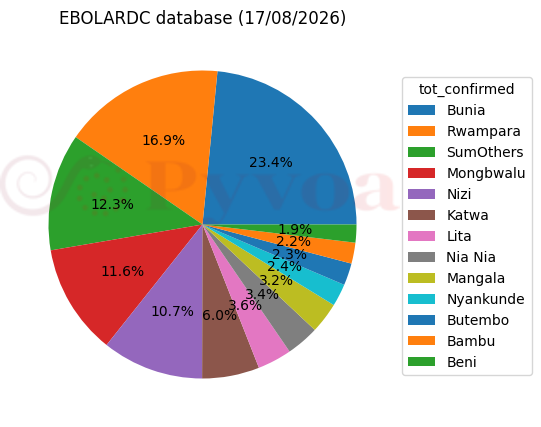

<Axes: title={'center': 'EBOLARDC database (17/08/2026)'}>

In [15]:
pf.setwhom('ebolardc')
pf.hist(which='tot_confirmed',typeofhist='pie')

In [16]:
save("fig5_ebola_drc.pdf")

Figure : paper/figures/fig5_ebola_drc.pdf  has been saved 
-> paper/figures/fig5_ebola_drc.pdf


## 6. The geolocation layer on its own *(not a manuscript listing)*

Supports the claim made in §2.1 and §4 that `pyvoa.geo` is importable
independently and contains nothing epidemiological. Any dataset keyed by
country, region or French *département* can be reconciled and mapped with it.

`GeoRegion.__init__` fetches about ten upstream pages, so the first run of this
cell is slower than the rest.

['France', 'United States', 'China', "Côte d'Ivoire"]
27 ISO3 codes, e.g. ['AUT', 'BEL', 'BGR', 'CYP', 'CZE']


<Axes: >

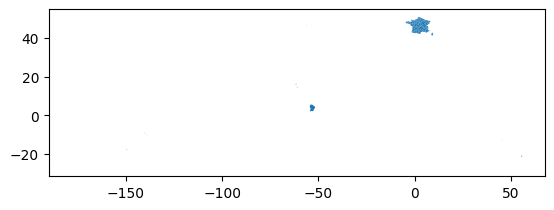

In [18]:
import pyvoa.geo as pg

gm = pg.GeoManager('name')
print(gm.to_standard(['fr', 'US', 'china', "cote d'ivoire"], output='list'))

eu = gm.get_GeoRegion().get_countries_from_region('European Union')
print(len(eu), 'ISO3 codes, e.g.', eu[:5])

fra = pg.GeoCountry('FRA')
fra.get_region_list()
fra.get_data().plot()

## 7. Wastewater against reported incidence *(not a manuscript listing — §4, point 1)*

The concrete illustration suggested for the Impact section: two unrelated
providers, one query grammar, one geographic key. Because both frames carry the
same `date` and `where` columns, putting the two signals on one axis is a merge
rather than a reconciliation exercise.

In [19]:
pf.setwhom('sumeau')
waste = pf.get(which='ratio', what='current', output='pandas')
print('sumeau     ', waste.shape, waste['date'].min(), '..', waste['date'].max())

pf.setwhom('spfnational')
cases = pf.get(which='cur_cas', what='daily', option='smooth7',
               output='pandas')
print('spfnational', cases.shape, cases['date'].min(), '..', cases['date'].max())

merged = waste.merge(cases, on=['date', 'where'], suffixes=('_waste', '_cases'))
print('overlapping rows:', len(merged))
merged.head()

Few information concernant the selected database :  sumeau
Available key-words, which ∈ ['ratio']
Example of where :  ['R', 'A', 'R']  ...
Last date data  2026-01-12
First date data  2022-08-08
Memory usage of all columns: 243,408 bytes
sumeau      (1254, 7) 2022-08-08 00:00:00 .. 2026-01-12 00:00:00
Few information concernant the selected database :  spfnational
Available key-words, which ∈ ['cur_cas', 'cur_hospitalises', 'cur_reanimation', 'cur_tx_pos', 'tot_dc', 'tot_dc_esms', 'tot_dc_hosp']
Example of where :  ['F', 'F', 'F']  ...
Last date data  2023-06-30
First date data  2020-01-23
Memory usage of all columns: 303,842 bytes
spfnational (1255, 13) 2020-01-23 00:00:00 .. 2023-06-30 00:00:00
overlapping rows: 327


,date,where,ratio,ratio daily,ratio weekly,shortenwhere_waste,code_waste,cur_cas,cur_cas daily,cur_cas weekly,cur_hospitalises,cur_reanimation,cur_tx_pos,shortenwhere_cases,tot_dc,tot_dc_esms,tot_dc_hosp,code_cases
0,2022-08-08,France,1156.103144,0.0,0.0,France,FRA,30404.857143,-308.428571,-15791.000000,995.0,99.0,21.64,France,152711.0,29054.0,123657.0,FRA
1,2022-08-09,France,1156.103144,0.0,0.0,France,FRA,28077.857143,-2327.000000,-13397.571429,1019.0,103.0,21.31,France,152822.0,29054.0,123768.0,FRA
2,2022-08-10,France,1156.103144,0.0,0.0,France,FRA,26405.428571,-1672.428571,-12234.285714,812.0,66.0,21.08,France,152910.0,29062.0,123848.0,FRA
3,2022-08-11,France,1156.103144,0.0,0.0,France,FRA,25050.142857,-1355.285714,-11047.428571,801.0,82.0,20.83,France,152990.0,29062.0,123928.0,FRA
4,2022-08-12,France,1156.103144,0.0,0.0,France,FRA,23913.857143,-1136.285714,-10051.857143,703.0,82.0,20.72,France,153064.0,29067.0,123997.0,FRA


## Producing the manuscript figures

The `save()` cells above write **PDF**, which is the vector artwork Elsevier
asks for and what `\includegraphics` pulls in from the `.tex`. The backends
render to whatever extension the filename carries, so a `.png` there would give
raster art instead.

A script version of this notebook, `paper_examples.py`, runs the same listings
headless (`matplotlib.use('Agg')`) and offers `--check` for the vocabulary test
of §1 alone. Its examples 1-4 are these four listings and write the same four
files; its examples 5 and 6 are the two cells above that are not listings.
Either file, deposited alongside the manuscript or in `examples/pyfiles/` of the
repository, can serve as the reproducible capsule requested in metadata fields
C3 and S3.